In [14]:
import numpy as np
import matplotlib.pyplot as plt

# governing equations of acceleration of the system
def calculate_acceleration(pos_1,
                           pos_2,
                           pos_3,
                           mass, 
                           grav):
                           
    a_1 = -grav*mass[1]*((pos_1-pos_2)/(np.linalg.norm(pos_1 - pos_2, 2)**3)) -grav*mass[2]*((pos_1-pos_3)/(np.linalg.norm(pos_1 - pos_3, 2)**3))
    a_2 = -grav*mass[2]*((pos_2-pos_3)/(np.linalg.norm(pos_2 - pos_3, 2)**3)) -grav*mass[0]*((pos_2-pos_1)/(np.linalg.norm(pos_2 - pos_1, 2)**3))
    a_3 = -grav*mass[0]*((pos_3-pos_1)/(np.linalg.norm(pos_3 - pos_1, 2)**3)) -grav*mass[1]*((pos_3-pos_2)/(np.linalg.norm(pos_3 - pos_2, 2)**3))

    return a_1, a_2, a_3

In [8]:
def run_sim(mass,
            grav,
            p_1,
            p_2,
            p_3,
            v_1,
            v_2,
            v_3,
            run_time,
            dt
            ):

    # initialize logging arrays
    times = np.linspace(0, run_time, int(run_time/dt))
    pos_1 = np.zeros((3, len(times)))
    vel_1 = np.zeros((3, len(times)))
    pos_2 = np.zeros((3, len(times)))
    vel_2 = np.zeros((3, len(times)))
    pos_3 = np.zeros((3, len(times)))
    vel_3 = np.zeros((3, len(times)))

    # fill initial
    pos_1[:, 0] = p_1
    vel_1[:, 0] = v_1
    pos_2[:, 0] = p_2
    vel_2[:, 0] = v_2
    pos_3[:, 0] = p_3
    vel_3[:, 0] = v_3

    # run sim
    for i in range(1, len(times)):

        # calculate new accelerations
        a_1, a_2, a_3 = calculate_acceleration(
            pos_1=pos_1[:, i-1],
            pos_2=pos_2[:, i-1],
            pos_3=pos_3[:, i-1],
            mass=mass,
            grav=grav
        )

        # calculate new velocities
        v_1 = vel_1[:, i-1] + dt*a_1
        v_2 = vel_2[:, i-1] + dt*a_2
        v_3 = vel_3[:, i-1] + dt*a_3

        # calculate new positions
        p_1 = pos_1[:, i-1] + dt*v_1
        p_2 = pos_2[:, i-1] + dt*v_2
        p_3 = pos_3[:, i-1] + dt*v_3

        pos_1[:, i] = p_1
        vel_1[:, i] = v_1
        pos_2[:, i] = p_2
        vel_2[:, i] = v_2
        pos_3[:, i] = p_3
        vel_3[:, i] = v_3
    
    data = {
        'times': times,
        'pos_1': pos_1,
        'pos_2': pos_2,
        'pos_3': pos_3,
        'vel_1': vel_1,
        'vel_2': vel_2,
        'vel_3': vel_3
    }
        
    
    return data

In [17]:
# define initial conditions and run sim
grav = 9.2
mass = np.array([10, 20, 30])
init_p_1 = np.array([10, 20, 20])
init_p_2 = np.array([0, 0, 0])
init_p_3 = np.array([30, 12, 10])
init_v_1 = np.array([0.1, 3, 2])
init_v_2 = np.array([0.1, 0.02, 0.05])
init_v_3 = np.array([0.01, 0.09, 4])
run_time = 100
dt = 0.001

data = run_sim(
    mass=mass,
    grav=grav,
    p_1=init_p_1,
    p_2=init_p_2,
    p_3=init_p_3,
    v_1=init_v_1,
    v_2=init_v_2,
    v_3=init_v_3,
    run_time=run_time,
    dt=dt
)

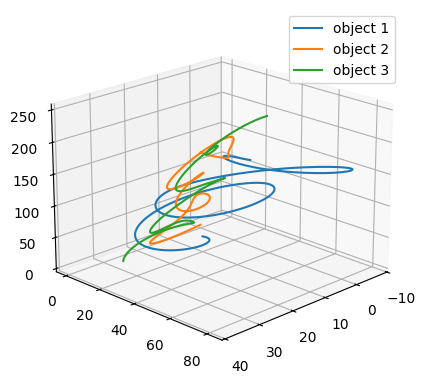

In [20]:
x_1, y_1, z_1 = np.array_split(data['pos_1'], 3, axis=0)
x_2, y_2, z_2 = np.array_split(data['pos_2'], 3, axis=0)
x_3, y_3, z_3 = np.array_split(data['pos_3'], 3, axis=0)


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=20, azim=45)
ax.plot(x_1, y_1, z_1, label='object 1')
ax.plot(x_2, y_2, z_2, label='object 2')
ax.plot(x_3, y_3, z_3, label='object 3')
plt.legend()
plt.show()